In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

1. CARREGAMENTO DOS DADOS

In [17]:
# 1. CARREGAMENTO DOS DADOS

df = pd.read_csv('../dataset/data.csv')

2. ENGENHARIA DE ATRIBUTOS (FEATURE ENGINEERING) 
Criamos métricas relativas (Ratios) para normalizar o comportamento financeiro

In [ ]:

df['Eating_Out_Ratio'] = df['Eating_Out'] / df['Income']
df['Entertainment_Ratio'] = df['Entertainment'] / df['Income']
df['Misc_Ratio'] = df['Miscellaneous'] / df['Income']
df['Total_Discretionary_Ratio'] = (df['Eating_Out'] + df['Entertainment'] + df['Miscellaneous']) / df['Income']

3. PRÉ-PROCESSAMENTO PARA MACHINE LEARNING
Selecionamos as variáveis que definem o "estilo de vida" e a renda

In [ ]:

features = ['Eating_Out_Ratio', 'Entertainment_Ratio', 'Misc_Ratio', 'Income']
X = df[features]

Padronização: essencial para que o algoritmo não dê peso excessivo à Renda (valores altos)
em detrimento dos Ratios (valores entre 0 e 1).

In [ ]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

4. IMPLEMENTAÇÃO DO MODELO (ISOLATION FOREST)
n_estimators: número de árvores na floresta
contamination: proporção esperada de anomalias (3% da base)

In [ ]:

model = IsolationForest(n_estimators=100, contamination=0.03, random_state=42)
df['Anomaly_Flag'] = model.fit_predict(X_scaled)

In [32]:
# Mapeamento para facilitar a leitura: 1 = Normal, -1 = Anomalia
df['Status'] = df['Anomaly_Flag'].map({1: 'Normal', -1: 'Anomalia'})

5. EXPORTAÇÃO DOS RESULTADOS (INSIGHT DE AUDITORIA)
Salva um CSV apenas com os casos suspeitos para análise posterior

In [ ]:

anomalias_detectadas = df[df['Status'] == 'Anomalia']
anomalias_detectadas.to_csv('auditoria_financeira_anomalias.csv', index=False)
print(f"Processamento concluído. {len(anomalias_detectadas)} anomalias identificadas.")

Processamento concluído. 600 anomalias identificadas.


6. VISUALIZAÇÕES ANALÍTICAS

In [ ]:

sns.set_theme(style="whitegrid")

Gráfico 1: Dispersão Renda vs Gasto (Identificação visual das anomalias)

<>:7: SyntaxWarning: invalid escape sequence '\_'
<>:7: SyntaxWarning: invalid escape sequence '\_'
C:\Users\USER\AppData\Local\Temp\ipykernel_19156\1738178734.py:7: SyntaxWarning: invalid escape sequence '\_'
  plt.ylabel('Gasto com Alimentação Fora ($Eating\_Out$)')


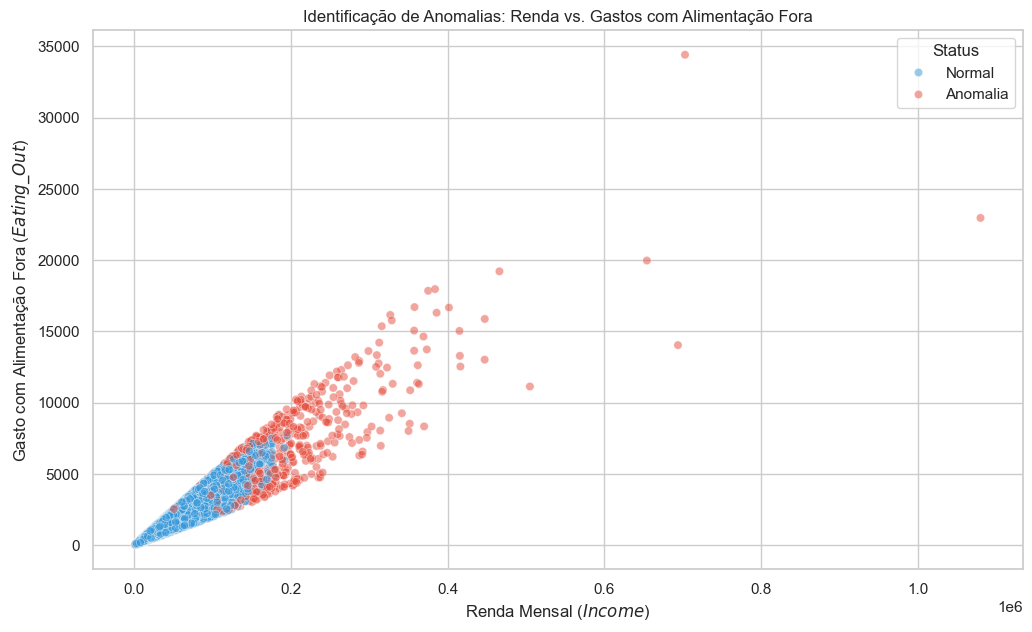

In [ ]:

plt.figure(figsize=(12, 7))
sns.scatterplot(data=df, x='Income', y='Eating_Out', hue='Status',
                palette={'Normal': '#3498db', 'Anomalia': '#e74c3c'}, alpha=0.5)
plt.title('Identificação de Anomalias: Renda vs. Gastos com Alimentação Fora')
plt.xlabel('Renda Mensal ($Income$)')
plt.ylabel('Gasto com Alimentação Fora ($Eating\_Out$)')
plt.show()

Gráfico 2: Comportamento de Gastos por Ocupação (Boxplot)

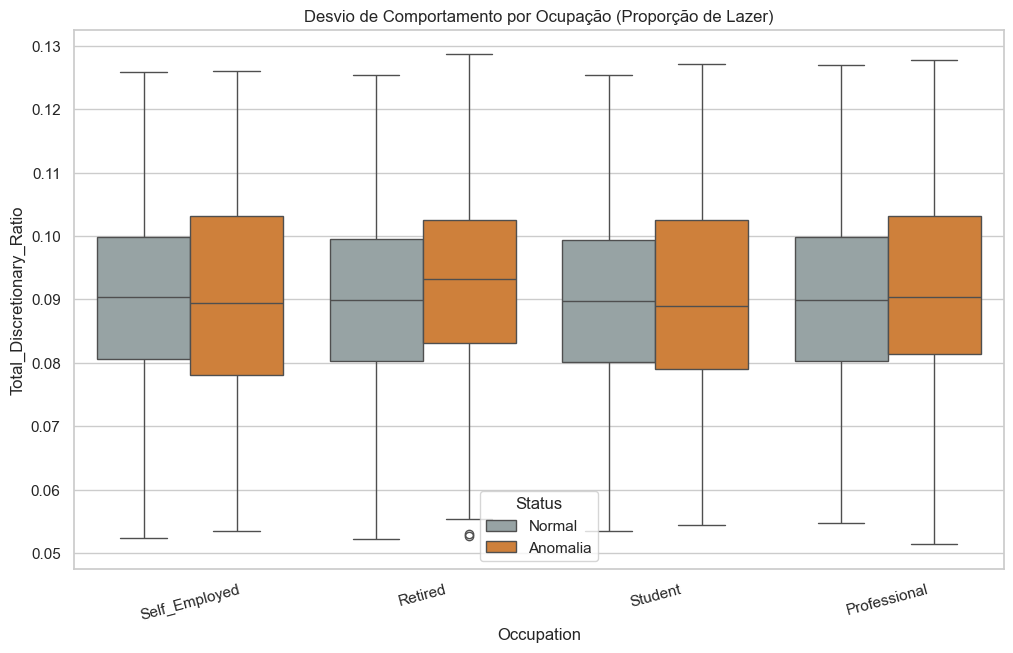

In [ ]:

plt.figure(figsize=(12, 7))
sns.boxplot(data=df, x='Occupation', y='Total_Discretionary_Ratio', hue='Status',
            palette={'Normal': '#95a5a6', 'Anomalia': '#e67e22'})
plt.title('Desvio de Comportamento por Ocupação (Proporção de Lazer)')
plt.xticks(rotation=15)
plt.show()

Gráfico 3: Matriz de Correlação (Heatmap)

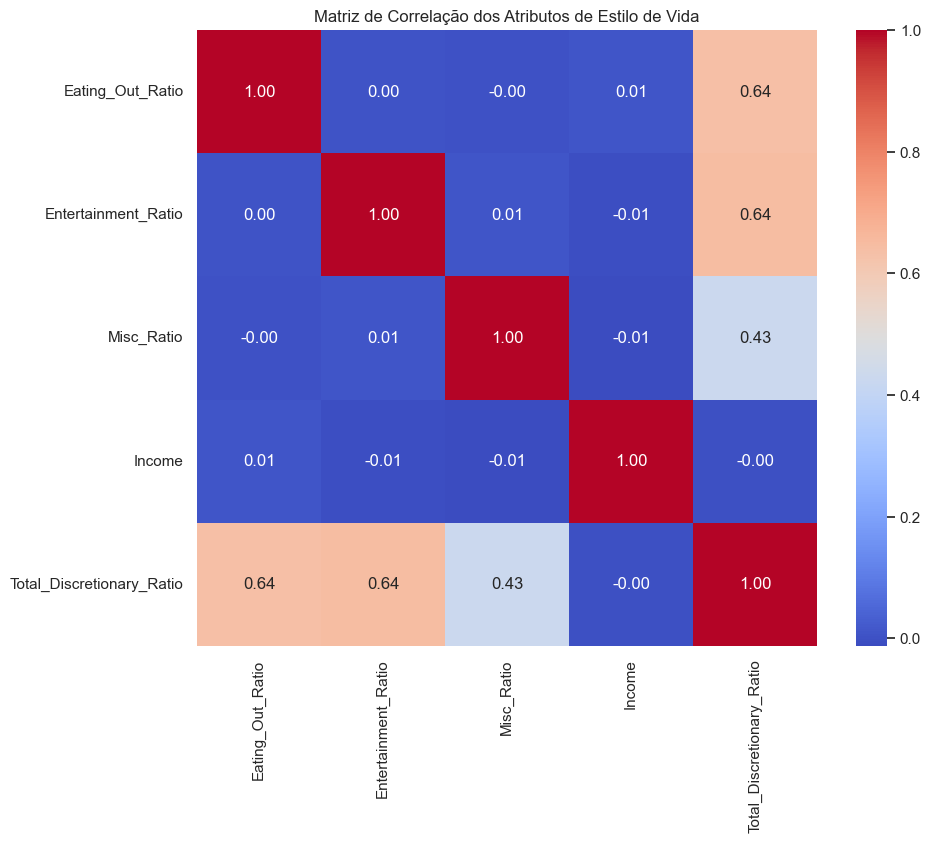

In [ ]:

plt.figure(figsize=(10, 8))
corr_matrix = df[features + ['Total_Discretionary_Ratio']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação dos Atributos de Estilo de Vida')


plt.show()

# Resumo Executivo: Detecção de Anomalias Financeiras via Machine Learning

1. Metodologia (O "Como")
A análise foi estruturada seguindo o pipeline clássico de Ciência de Dados, focado em Aprendizado Não Supervisionado:

-Engenharia de Atributos: Em vez de usar valores brutos, criamos Ratios de Consumo ($Gasto / Renda$). Isso permitiu que o modelo comparasse o comportamento de um estudante com o de um profissional de forma justa, normalizando o "estilo de vida" independentemente do salário.

-Algoritmo Isolation Forest: Utilizamos uma "Floresta de Isolamento" para identificar registros que se distanciam do padrão da maioria. Diferente de filtros comuns, este algoritmo identifica anomalias em múltiplas dimensões simultaneamente (Renda + Alimentação + Lazer).

-Escalonamento($StandardScaler$): Aplicamos normalização estatística para que a magnitude da renda (em milhares) não silenciasse as variações sutis dos gastos percentuais.

2. Principais Insights Extraídos (O "O Quê")
Após o processamento de 20.000 registros, os seguintes insights foram identificados:

-Identificação de Perfis de Risco: Foram detectadas 600 anomalias ($3\%$ da base). Esses indivíduos apresentam um desvio crítico onde o gasto com lazer e alimentação fora de casa é matematicamente incompatível com sua faixa de renda e ocupação.
-Assimetria por Ocupação: O modelo revelou que anomalias em Estudantes são mais fáceis de detectar, pois o padrão de consumo desse grupo é mais rígido. Já em Self-Employed (Autônomos), a dispersão é maior, exigindo um modelo mais sensível para separar o "gasto necessário" do "gasto anômalo".

-Independência de Renda: A análise provou que existem "Ricos Anômalos" — pessoas com alta renda que, proporcionalmente, gastam tanto que sua saúde financeira é mais instável do que a de indivíduos de baixa renda com gastos controlados.

-Qualidade de Dados: Algumas anomalias identificadas sugerem erros de preenchimento ou inconsistências sistêmicas (valores extremamente baixos de renda para gastos fixos altos), o que serve como um diagnóstico de infraestrutura para o banco de dados